In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [3]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

f:\Desktop\AgenticAIWorkspace\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [4]:
urls =  [
    "https://python.langchain.com/docs/get_started/introduction/",
    "https://python.langchain.com/docs/tutorials/",
    "https://python.langchain.com/docs/how_to/"]

In [5]:
docs = [WebBaseLoader(url).load() for url in urls]
print(docs)

[[Document(metadata={'source': 'https://python.langchain.com/docs/get_started/introduction/', 'title': 'Quickstart - Docs by LangChain', 'language': 'en'}, page_content='Quickstart - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationGet startedQuickstartDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsAdvanced usageGuardrailsRuntimeContext engineeringModel Context Protocol (MCP)Human-in-the-loopMulti-agentRetrievalLong-term memoryAgent developmentLangSmith StudioTestAgent Chat UIDeploy with LangSmithDeploymentObservabilityOn this pageRequirementsBuild a basic a

In [6]:
doc_list = [doc for sublist in docs for doc in sublist]
print(doc_list)

[Document(metadata={'source': 'https://python.langchain.com/docs/get_started/introduction/', 'title': 'Quickstart - Docs by LangChain', 'language': 'en'}, page_content='Quickstart - Docs by LangChainSkip to main contentJoin us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets >Docs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationGet startedQuickstartDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsAdvanced usageGuardrailsRuntimeContext engineeringModel Context Protocol (MCP)Human-in-the-loopMulti-agentRetrievalLong-term memoryAgent developmentLangSmith StudioTestAgent Chat UIDeploy with LangSmithDeploymentObservabilityOn this pageRequirementsBuild a basic ag

In [7]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
split_docs = text_splitter.split_documents(doc_list)
vectorestore = FAISS.from_documents(documents = split_docs,embedding=HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2"))
retriever = vectorestore.as_retriever()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1384.58it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
from langchain_groq import ChatGroq
llm = ChatGroq(model_name = "llama-3.3-70b-versatile",api_key = groq_api_key)

In [9]:
from pydantic import BaseModel,Field
from typing import Literal
from langchain_core.prompts import ChatPromptTemplate

class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""

    datasource:Literal["web search","vectorestore"]=Field(description="Given a user question choose to route it to web search or a vectorstore.")
    
llm = ChatGroq(model_name = "llama-3.3-70b-versatile",api_key = groq_api_key)
llm = llm.with_structured_output(RouteQuery)

system = """You are an expert at routing a user question to a vectorstore or web search,The vectorstore contains documents
            related to langchain, related to agents, prompt engineering, langchain tutorials, and adversial attacks."""

route_prompt = ChatPromptTemplate.from_messages([("system",system),("human","{question}")])
route_chain = route_prompt | llm
result = route_chain.invoke({"question":"What is langchain?"})
print(result)

datasource='vectorestore'


In [10]:
from langchain_community.tools.tavily_search import TavilySearchResults
web_search_tool = TavilySearchResults(k = 3)

C:\Users\Alok\AppData\Local\Temp\ipykernel_18220\1709393113.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(k = 3)


In [11]:
# retriever grader 

# data model
from pydantic import BaseModel, Field
class gradedocuments(BaseModel):
    """Binary score for relavance check on retrieved documents."""
    binary_score : str=Field(description="Documents are relevant to the question, 'yes' or 'no'")
    
llm = ChatGroq(model_name = "llama-3.3-70b-versatile",api_key = groq_api_key)
llm = llm.with_structured_output(gradedocuments)

# prompt
system = """You are a grader assessing of a retrieved relevance of a retrieved document to a user question. \n
            If the document contains Keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
            It does not need to be a stringent test. the goal is to filter out erroneous retrievals. \n
            Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages([("system",system),("human","Retrieved document: \n\n {document} User Question: {question}")])
grade_chain = grade_prompt | llm
question = "what is langchain?"
docs = retriever.invoke(question)
doc_text = docs[1].page_content
response = grade_chain.invoke({"document":doc_text, "question":question})
print(response)

binary_score='yes'


In [12]:
# generate

from langchain_classic import hub
from langchain_core.output_parsers import StrOutputParser

prompt = hub.pull("rlm/rag-prompt")

    
llm = ChatGroq(model_name = "llama-3.3-70b-versatile",api_key = groq_api_key)
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)
rag_chain = prompt | llm | StrOutputParser()
generation = rag_chain.invoke({"context":docs,"question":question})
print(generation)

LangChain is an open-source framework with a prebuilt agent architecture and integrations for any model or tool. It allows users to build agents that adapt as fast as the ecosystem evolves. LangChain provides a range of features, including prebuilt middleware, custom middleware, and integrations for various models and tools.


In [13]:
# Hallucination grader
class GradeHallucination(BaseModel):
    """Binary score for Hallucination present in generation number."""
    binary_score:str=Field(description="Answer is grounded in the facts, 'yes' or 'no'.")

llm = ChatGroq(model_name = "llama-3.3-70b-versatile",api_key = groq_api_key)
llm = llm.with_structured_output(GradeHallucination)

system = """You are a grader assessing whether an llm generation is grounded in / supported by a set of retieved facts. \n
            Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""

Hallucination_prompt = ChatPromptTemplate.from_messages([("system",system),("human","Set of facts: \n\n {documents} LLM genration : {generation}")])
Hallucination_chain = Hallucination_prompt | llm
response = Hallucination_chain.invoke({"documents":docs,"generation":generation})
print(response)

binary_score='yes'


In [14]:
# data model
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""
    binary_score:str=Field(description="Answer addresses the question, 'yes' or 'no'")

llm = ChatGroq(model_name = "llama-3.3-70b-versatile",api_key = groq_api_key)
llm = llm.with_structured_output(GradeAnswer)
system = """You are a grader assessing whether an answer addresses/resolves a question\n
            Give the binary score 'yes' or 'no'. 'yes' means that the answer resolves the question."""

answer_prompt = ChatPromptTemplate.from_messages([("system",system),("human","User question: \n\n {question} LLM Generation:{generation}")])
answer_chain = answer_prompt | llm
answer_response = answer_chain.invoke({"question":question,"generation":generation})
print(answer_response)

binary_score='yes'


In [15]:
# transform the query or rewrite the question

system = """You are a question rewriter that converts an input question to a better version that is optimized \n
            for vectorestore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""
llm = ChatGroq(model_name = "llama-3.3-70b-versatile",api_key = groq_api_key)
rewrite_prompt = ChatPromptTemplate.from_messages([("system",system),("human","Here is the intial question: \n\n {question} \n formulate an improved question.")])
question_rewriter_chain = rewrite_prompt | llm
rewrittern_question = question_rewriter_chain.invoke({"question":question})
def format_answer(rewrittern_question):
    return "\n\n".join(rewrittern_question.content)
print(rewrittern_question.content)

Here's a rewritten version of the question that's optimized for vector search retrieval:

"What is LangChain, and how does it relate to large language models and AI applications?"

This revised question provides more context and specificity, which can help the vector search model understand the underlying semantic intent and retrieve more relevant information. 

Alternatively, another version could be: 

"Provide an overview of LangChain, including its definition, key features, and use cases in natural language processing and machine learning."

This version is even more specific and provides clear guidance on the type of information being sought, which can lead to more accurate and relevant results.


In [16]:
from typing_extensions import TypedDict
from typing import List

class GraphState(TypedDict):
    question:str
    generation:str
    documents:List[str]

In [17]:
# retrieve
def retrieve(state:GraphState):
    """Retrieve documents
    
        Args:
            state(dict) : the current graph state.
            
        Return:
            state(dict): New key added to state, documents, that contains retrieved documents."""
    print("---RETRIEVE---")
    question = state["question"]
    documents = retriever.invoke(question)
    return {"question":question,"documents":documents}

In [18]:
# generate
def generate(state:GraphState):
    """Generate Answer
    
    Args: 
        state(dict): The current graph state.
    Returns:
        state(dict): New key added to state, generation, that contains the generate answer."""
    
    print("---GENERATE---")
    documents = state["documents"]
    question = state["question"]
    generate = rag_chain.invoke({"context":documents,"question":question})
    return {"generation":generate,"question":question,"documents":documents}

In [32]:
def grade_documents(state:GraphState):
    """Determines whether the retrieved documents are relevant or not.
    
    Args: 
        state(dict): The current graph state.
    Returns:
        state(dict): Updated documents key with only filtered relevant documents."""
    
    question = state["question"]
    documents = state["documents"]
    
    filtered_documents = []
    for d in documents:
        score = grade_chain.invoke({"document":d.page_content,"question":question})
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENTS ARE RELEVANT")
            filtered_documents.append(d)
        else:
            print("---GRADE: DOCUMENTS ARE NOT RELEVANT")
            continue
    return {"documents":filtered_documents,"question":question}

In [20]:
def transform_query(state:GraphState):
    """Transform the query to perform the better question.
    Args:
        state(dict): The current graph state.
    Returns:
        state(dict): Updated the query with a re-phrased question."""
    
    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]
    rephrased_question = question_rewriter_chain.invoke({"question":question})
    return {"question":rephrased_question,"documents":documents}

In [21]:
from langchain_core.documents import Document
def web_search(state:GraphState):
    """Web-search based on re-phrased question
       Args:
            state(dict): The current graph state
        Returns:
            Update documents with key appended web results."""
    
    print("---WEB SEARCH---")
    question = state["question"]

    docs = web_search_tool.invoke({"query":question})
    # def format_docs(docs):
    #     return "\n\n".join(d["content"] for d in docs)
    web_result_updated = "\n".join([d["content"] for d in docs])
    web_results = Document(page_content = web_result_updated)
    return {"documents":web_results,"question":question}
    

In [22]:
# Edges
def route_question(state:GraphState):
    """Route to web_search or RAG
    
        Args:
            state(dict): The current graph state
        Returns:
            str: Next Node to call"""
    question = state["question"]
    source = route_chain.invoke({"question":question})
    if source.datasource == "web search":
        print("---Route question to web search")
        return "web_search"
    elif source.datasource == "vectorestore":
        print("---Route question to RAG---")
        return "vectorestore"

In [23]:
def decide_to_generate(state:GraphState):
    """Whether to generate an answer or re-phrased the query
        Args:
            state(dict): The current graph state
        Returns:
            str: Next Node to call"""
    filtered_documents = state["documents"]
    if not filtered_documents:
        print("---Decision: All documents are not relevant to question, Transform the query")
        return "transform_query"
    else:
        print("---Decision: All documents are relevant to question, Generate the answer")
        return "generate"

In [24]:
def grade_generation_v_documents_and_question(state:GraphState):
    """Determines whether the generation is grounded in the document and answer question.
        Args:
            state(dict): The current graph state.
        Returns:
            str: Next node to call"""
    
    print("---CHECK HALLUCINATIONS---")

    documents = state["documents"]
    generation = state["generation"]
    question = state["question"]

    Hallucination_score = Hallucination_chain.invoke({"documents": documents,"generation":generation})
    if Hallucination_score.binary_score == "yes":
        print("---Decision: Generation is grounded in documents---")
        # check answer grader
        answer_score = answer_chain.invoke({"question":question,"generation":generation})
        if answer_score.binary_score == "yes":
            print("---Decision: Generation addresses question---")
            return "useful"
        else:
            print("---Decision: Generation does not addresses question---")
            return "not useful"
    else:
        print("---decision: Generation is not grounded in documents---")
        return "not supported"

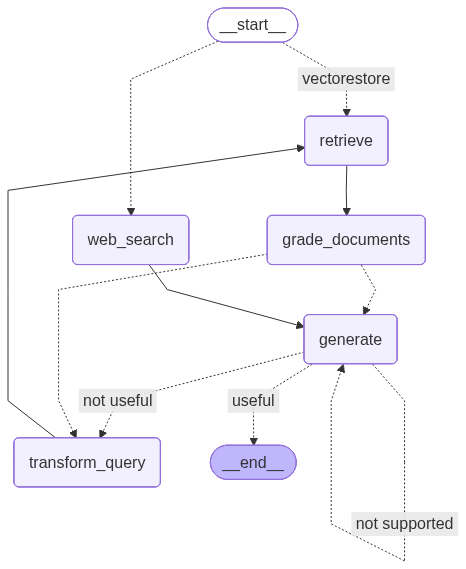

In [33]:
from langgraph.graph import StateGraph,START,END
from IPython.display import display,Image
graph = StateGraph(GraphState)

# adding the nodes

graph.add_node("retrieve",retrieve)
graph.add_node("transform_query",transform_query)
graph.add_node("generate",generate)
graph.add_node("grade_documents",grade_documents)
graph.add_node("web_search",web_search)

# adding the edges
graph.add_conditional_edges(START,route_question,{"web_search":"web_search","vectorestore":"retrieve"})
graph.add_edge("web_search","generate")
graph.add_edge("retrieve","grade_documents")

graph.add_conditional_edges("grade_documents",decide_to_generate,{"transform_query":"transform_query","generate":"generate"})

graph.add_edge("transform_query","retrieve")
graph.add_conditional_edges("generate",grade_generation_v_documents_and_question,{"useful":END,"not useful": "transform_query","not supported":"generate"})

graph_builder = graph.compile()

visualization_graph = graph_builder.get_graph().draw_mermaid_png()

display(Image(visualization_graph))

In [36]:
result = graph_builder.invoke({"question":"what is machine learning?"})
print(result["generation"])

---Route question to web search
---WEB SEARCH---
---GENERATE---
---CHECK HALLUCINATIONS---
---Decision: Generation is grounded in documents---
---Decision: Generation addresses question---
Machine learning is a subset of artificial intelligence (AI) focused on algorithms that can "learn" patterns from training data and make accurate inferences about new data. It enables models to make decisions or predictions without explicit programming instructions, using pattern recognition to generalize to unseen data. Machine learning is a field of study concerned with the development of statistical algorithms that can learn from data and perform tasks without explicit programming language instructions.


In [37]:
result = graph_builder.invoke({"question":"what is compiler design?"})
print(result["generation"])

---Route question to web search
---WEB SEARCH---
---GENERATE---
---CHECK HALLUCINATIONS---
---Decision: Generation is grounded in documents---
---Decision: Generation addresses question---
Compiler design is the process of developing a compiler, which is software that translates or converts a program written in a high-level language into a low-level language. It involves many stages, such as lexical analysis, syntax analysis, semantic analysis, code generation, and code optimization. The main objective of compiler design is to automate the translation process, check the correctness of input code, and report errors in the source code.
